# Mandatory Assignment 1

#### Student Numbers: 161612, 160364, 185903, 186634

<h2 style="color:darkgreen;">Question 1. Exploratory Data Analysis (EDA)</h2>

### Importing dataset

In [6]:
import pandas as pd
import numpy as np

df = pd.read_excel("greenhouse-gas-emissions.xlsx")

df.head() # loading the uk sheet

,Final UK territorial greenhouse gas emissions statistics 1990-2024 - datasets of emissions by source
0,The two datasets in this file present UK terri...
1,Both datasets include more detailed breakdowns...
2,The 'UK_by_source' dataset includes emissions ...
3,The UK has two geographical coverages that it ...
4,Note that in these statistics the entire time ...


### 1.1 Write a Python program to perform a covariance- and correlation-based analysis to examine relationships between emissions, sources, and activities across years. Do not use any built-in covariance or correlation functions. You must implement your own calculations.

In [9]:
### ---- COVARIANCE ANALYSIS ----

# 1) SELECT SHEET TO READ
df = pd.read_excel("greenhouse-gas-emissions.xlsx", sheet_name=2) # we select the third sheet (index 2) because it only has information about the UK

# 2) COLUMN NAMES
YEAR_COL = "Year" # store column names as variables
SOURCE_COL = "Source"
ACTIVITY_COL = "Activity"
EMISSIONS_COL = "Emissions (MtCO2e)"

# 3) CREATE DUMMIES AND BUILD NUMERIC DF
dummies = pd.get_dummies(df[[SOURCE_COL, ACTIVITY_COL]], prefix=[SOURCE_COL, ACTIVITY_COL]) # create dummies for source and activity columns, prefix adds SOURCE_COL or ACTIVITY_COL to each dummy column so we know if it is a source or activity column
df_numeric = pd.concat([df[[YEAR_COL, EMISSIONS_COL]], dummies], axis=1) # concat builds a new dataframe that contains year, emissions and the dummy columns

# 4) MANUAL COVARIANCE FUNCTION
def covariance(x, y):
    n = len(x) # counts the number of rows (observations), assume y is the same (same number of rows in each column)
    mean_x = sum(x) / n # find average of x (first variable)
    mean_y = sum(y) / n # find average of y (second variable)
    total = 0.0 # total starts at 0
    for i in range(n): # loops over indices until n-1
        total += (x[i] - mean_x) * (y[i] - mean_y) # how far x and y are from their mean multiplied is added to the total
    return total / (n - 1) # divide by n-1 (sample covariance formula)

emissions = df_numeric[EMISSIONS_COL].tolist() # convert emissions column into a list so it can be used in covariance function

# 4) APPLY COVARIANCE TO SOURCE AND PRINT TOP 5
cov_source_results = [] # create empty list to store source results

for col in df_numeric.columns: # loop through all columns
    if col.startswith("Source_"): # find all source columns 
        cov_value = covariance(emissions, df_numeric[col].tolist()) # take all values, turns them into a list so they can be used in covariance function and apply covariance function
        cov_source_results.append((col, cov_value)) # adds results to list

cov_source_results.sort(key=lambda x: abs(x[1]), reverse=True) # sort by strength (absolute value)

print("\n Top 5 Sources by Covariance:")
for i in cov_source_results[:5]: # takes first 5 sources from sorted list (top 5)
    print(i) # prints top 5 sources

# 5) APPLY COVARIANCE TO ACTIVITY AND PRINT TOP 5
cov_activity_results = [] # create empty list to store activity results

for col in df_numeric.columns:
    if col.startswith("Activity_"): # find all activity columns 
        cov_value = covariance(emissions, df_numeric[col].tolist()) # again, turn into list and apply covariance function
        cov_activity_results.append((col, cov_value))
        
cov_activity_results.sort(key=lambda x: abs(x[1]), reverse=True)

print("\n Top 5 Activities by Covariance:")
for i in cov_activity_results[:5]: # find top 5 activities
    print(i) # print top 5 activities


 Top 5 Sources by Covariance:
('Source_Power stations', 0.05650377492898744)
('Source_Domestic Space Heater', 0.022152634254800737)
('Source_Landfill', 0.016163159848382725)
('Source_Road transport - cars - urban driving', 0.01221770091173588)
('Source_Aircraft - international cruise', 0.011191783834357087)

 Top 5 Activities by Covariance:
('Activity_Natural gas', 0.06315847797096419)
('Activity_Coal', 0.03779848390402859)
('Activity_Spreading', -0.02150694590722398)
('Activity_DERV', 0.018786580505501346)
('Activity_Petrol', 0.01642830789472532)


In [10]:
### ---- CORRELATION ANALYSIS ----

# 1) STANDARD DEVIATION CALCULATION
def std_dev(x):
    n = len(x)
    mean_x = sum(x) / n
    
    total = 0
    for i in range(n):
        total += (x[i] - mean_x) ** 2 # for each value subtract the mean, square it and add it to the total 
    variance = total / (n - 1) # divide by n-1 to find sample variance
    return variance ** 0.5 # square root of variance to find stdev

# 2) USE STANDARD DEVIATION TO CALCULATE CORRELATION
def correlation(x, y):
    n = len(x)
    
    mean_x = sum(x) / n
    mean_y = sum(y) / n
    
    # calculate covariance
    total = 0
    for i in range(n): # loop through each paired observation
        total += (x[i] - mean_x) * (y[i] - mean_y) # for each pair calculate x’s deviation from mean, y’s deviation from mean, multiply them and add to total
    
    cov = total / (n - 1) # sample covariance
    
    return cov / (std_dev(x) * std_dev(y)) # divide covariance by standard deviations 

# 3) CREATE DUMMIES
source_cols = [c for c in df_numeric.columns if c.startswith("Source_")]
activity_cols = [c for c in df_numeric.columns if c.startswith("Activity_")]

emissions = df_numeric[EMISSIONS_COL].tolist() # again, convert emissions to list so it can be used in functions

# APPLY CORRELATION TO SOURCE AND PRINT TOP 5
corr_source_results = []  # empty list to store results

for col in df_numeric.columns:  # loop through all columns
    if col.startswith("Source_"):  # select source dummy columns
        corr_value = correlation(emissions, df_numeric[col].tolist())
        corr_source_results.append((col, corr_value)) # store (column name, correlation)

corr_source_results.sort(key=lambda x: abs(x[1]), reverse=True) # sort by strength (absolute value)

print("\nTop 5 Sources by Correlation:")
for i in corr_source_results[:5]: # print top 5
    print(i)

# APPLY CORRELATION TO SOURCE AND PRINT TOP 5
corr_activity_results = []  

for col in df_numeric.columns:
    if col.startswith("Activity_"):  # select activity dummy columns
        corr_value = correlation(emissions, df_numeric[col].tolist())
        corr_activity_results.append((col, corr_value))

corr_activity_results.sort(key=lambda x: abs(x[1]), reverse=True)

print("\nTop 5 Activities by Correlation:")
for i in corr_activity_results[:5]:
    print(i)


Top 5 Sources by Correlation:
('Source_Landfill', 0.25134172245794084)
('Source_Power stations', 0.14918661751376316)
('Source_Domestic Space Heater', 0.10491511640972477)
('Source_Aircraft - international cruise', 0.08770393805676727)
('Source_Road transport - cars - urban driving', 0.0782088867637499)

Top 5 Activities by Correlation:
('Activity_Natural gas', 0.10614293682934382)
('Activity_Coal', 0.07623929485956293)
('Activity_DERV', 0.03851062738692671)
('Activity_Clinker production', 0.034124946664473306)
('Activity_Petrol', 0.033402687166487276)


### 2.2 Write another Python program to visualise your findings from the previous step and briefly explain the observed emission patterns. Hints: You may consider using histograms, boxplots, and scatterplots

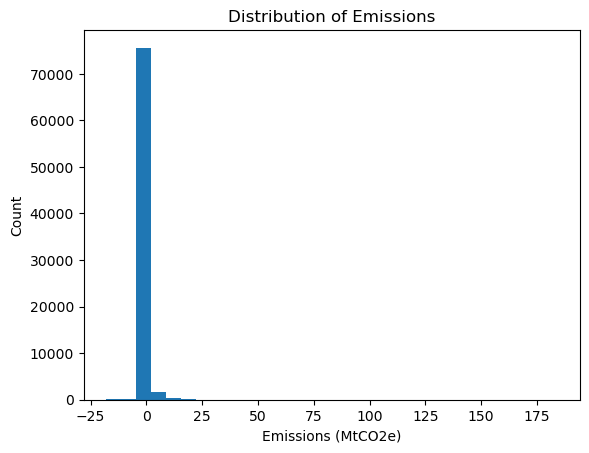

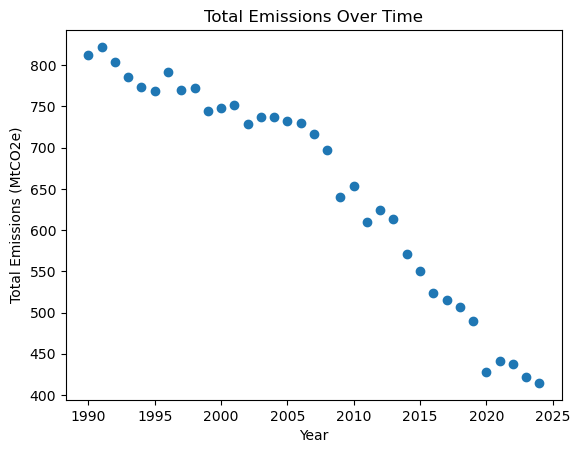

In [13]:
### --- GENERAL VISUALIZATIONS ---

import matplotlib.pyplot as plt

# 1) DISTRIBUTION OF EMISSIONS - HISTOGRAM
plt.figure()
plt.hist(df_numeric[EMISSIONS_COL].dropna().values, bins=30)
plt.title("Distribution of Emissions")
plt.xlabel("Emissions (MtCO2e)")
plt.ylabel("Count")
plt.show()

# 2) AGGREGATE EMISSIONS OVER TIME - SCATTER GRAPH
yearly_sum = (
    df_numeric[[YEAR_COL, EMISSIONS_COL]]
    .dropna()
    .groupby(YEAR_COL, as_index=False)[EMISSIONS_COL] # aggregate all rows from the same year together
    .sum() # add up all emissions for each year
    .sort_values(YEAR_COL) # sorts years chronologically
)

plt.figure()
plt.scatter(yearly_sum[YEAR_COL].values, yearly_sum[EMISSIONS_COL].values) 
plt.title("Total Emissions Over Time")
plt.xlabel("Year")
plt.ylabel("Total Emissions (MtCO2e)")
plt.show()

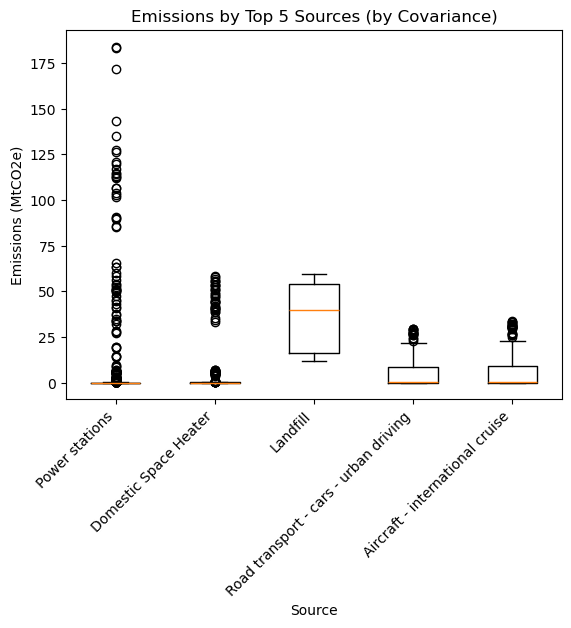

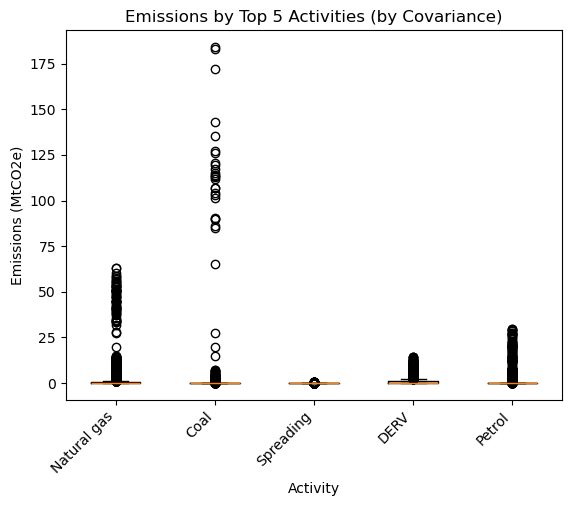

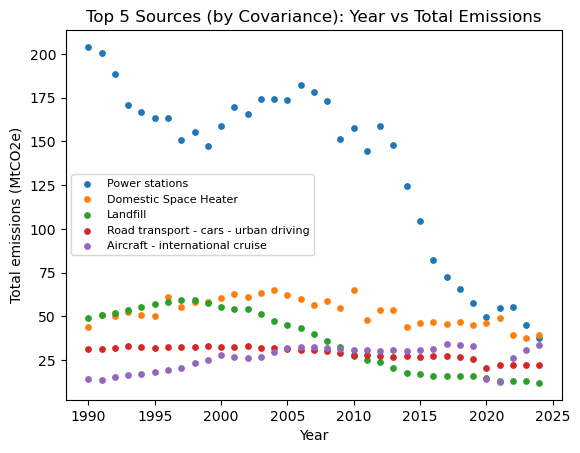

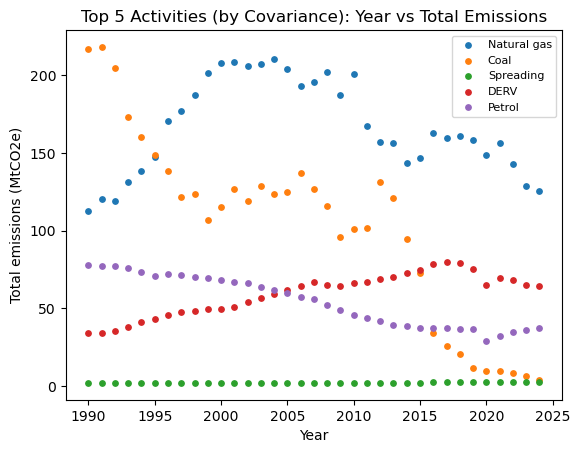

In [15]:
### ---- COVARIANCE VISUALIZATIONS ----

# 1) CHOOSE TOP 5 RESULTS TO VISUALIZE
top5_cov_sources = cov_source_results[:5] # already sorted by strength, choosing the first 5 values
top5_cov_activities = cov_activity_results[:5]

# 2) EXTRACT CLEAN NAMES (REMOVE DUMMY PREFIXES)
top_source_names = [x[0].replace("Source_", "") for x in top5_cov_sources] # loops through top 5 and removes the prefix for clean visualization labels
top_activity_names = [x[0].replace("Activity_", "") for x in top5_cov_activities]

# 2) EMISSIONS DISTRIBUTIONS FOR TOP 5 SOURCES (BY COVARIANCE) - BOXPLOT
plt.figure()
plt.boxplot(
    [df.loc[df[SOURCE_COL] == s, EMISSIONS_COL].dropna().values for s in top_source_names],
    tick_labels=top_source_names   # changed from labels=
)
plt.title("Emissions by Top 5 Sources (by Covariance)")
plt.xlabel("Source")
plt.ylabel("Emissions (MtCO2e)")
plt.xticks(rotation=45, ha="right")
plt.show()


# 3) EMISSIONS DISTRIBUTIONS FOR TOP 5 ACTIVITIES (BY COVARIANCE) - BOXPLOT
plt.figure()
plt.boxplot(
    [df.loc[df[ACTIVITY_COL] == a, EMISSIONS_COL].dropna().values for a in top_activity_names],
    tick_labels=top_activity_names   # changed from labels=
)
plt.title("Emissions by Top 5 Activities (by Covariance)")
plt.xlabel("Activity")
plt.ylabel("Emissions (MtCO2e)")
plt.xticks(rotation=45, ha="right")
plt.show()

# 4) YEARLY TOTAL FOR TOP SOURCES/ACTIVITIES OVER TIME - SCATTER PLOTS 
source_year = df.pivot_table(index=YEAR_COL, columns=SOURCE_COL, values=EMISSIONS_COL, aggfunc="sum").sort_index() # to visualize emissions, source and year all together create a pivot table
# rows are years, each source is a column, values are emissions, emissions are added together and years are sorted chronologically
activity_year = df.pivot_table(index=YEAR_COL, columns=ACTIVITY_COL, values=EMISSIONS_COL, aggfunc="sum").sort_index() # same thing but for activity

plt.figure()
for s in top_source_names: # loops through each top 5 source
    plt.scatter(source_year.index.values, source_year[s].values, label=s, s=15) # create scatter plot, with years on x axis and emissions on y
plt.title("Top 5 Sources (by Covariance): Year vs Total Emissions")
plt.xlabel("Year")
plt.ylabel("Total emissions (MtCO2e)")
plt.legend(fontsize=8)
plt.show()

plt.figure()
for a in top_activity_names: # loops through each top 5 activities
    plt.scatter(activity_year.index.values, activity_year[a].values, label=a, s=15) # create same scatter plot for activities
plt.title("Top 5 Activities (by Covariance): Year vs Total Emissions")
plt.xlabel("Year")
plt.ylabel("Total emissions (MtCO2e)")
plt.legend(fontsize=8)
plt.show()

/var/folders/16/s25ssv5x6256tg5wd0vpbttm0000gn/T/ipykernel_890/3771884336.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


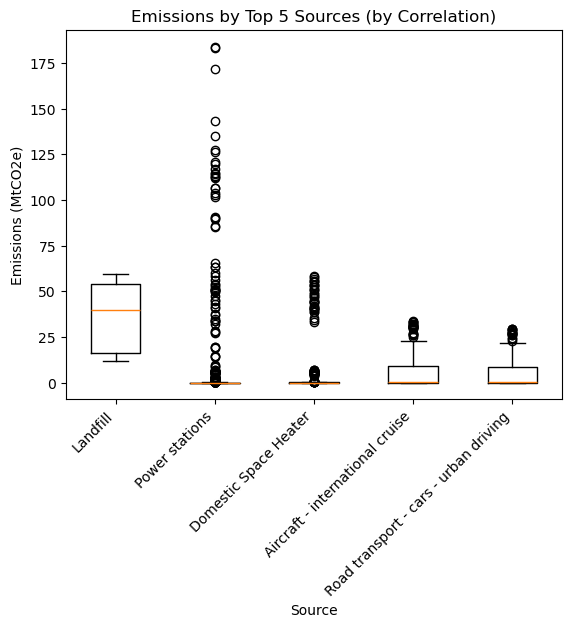

/var/folders/16/s25ssv5x6256tg5wd0vpbttm0000gn/T/ipykernel_890/3771884336.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


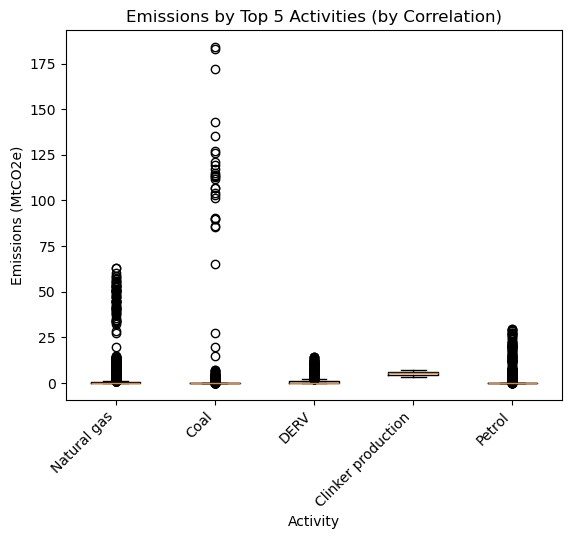

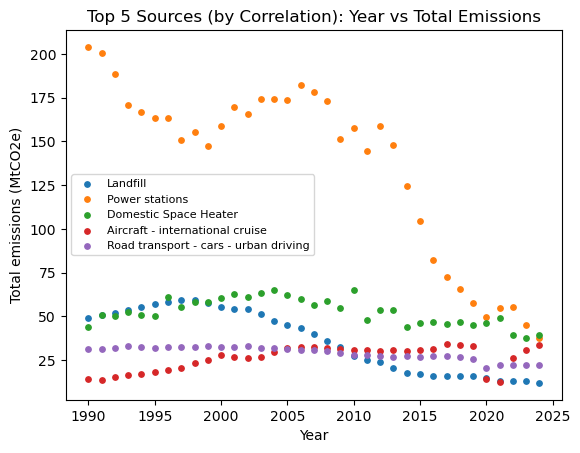

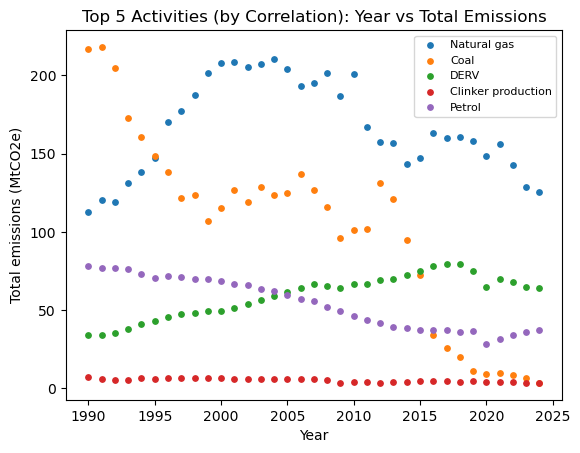

In [16]:
### --- CORRELATION VISUALIZATIONS ---

# 1) CHOOSE TOP 5 RESULTS TO VISUALIZE
top5_corr_sources = corr_source_results[:5] # first 5 values of sorted results  
top5_corr_activities = corr_activity_results[:5]

# 2) EXTRACT CLEAN NAMES (REMOVE DUMMY PREFIXES)
top_corr_source_names = [x[0].replace("Source_", "") for x in top5_corr_sources] # as before, remove dummy prefixes for clean visualization labels
top_corr_activity_names = [x[0].replace("Activity_", "") for x in top5_corr_activities]

# 3) EMISSIONS DISTRIBUTIONS FOR TOP 5 SOURCES (BY CORRELATION) - BOXPLOT
plt.figure()
plt.boxplot(
    [df.loc[df[SOURCE_COL] == s, EMISSIONS_COL].dropna().values for s in top_corr_source_names], # extract and group emissions by source
    labels=top_corr_source_names
)
plt.title("Emissions by Top 5 Sources (by Correlation)")
plt.xlabel("Source")
plt.ylabel("Emissions (MtCO2e)")
plt.xticks(rotation=45, ha="right")
plt.show()

# 4) EMISSIONS DISTRIBUTIONS FOR TOP 5 ACTIVITIES (BY CORRELATION) - BOXPLOT
plt.figure()
plt.boxplot(
    [df.loc[df[ACTIVITY_COL] == a, EMISSIONS_COL].dropna().values for a in top_corr_activity_names], # extract and group emissions by activity
    labels=top_corr_activity_names
)
plt.title("Emissions by Top 5 Activities (by Correlation)")
plt.xlabel("Activity")
plt.ylabel("Emissions (MtCO2e)")
plt.xticks(rotation=45, ha="right")
plt.show()

# 5) YEARLY TOTAL FOR TOP SOURCES/ACTIVITIES OVER TIME - SCATTER PLOTS 
source_year = df.pivot_table(index=YEAR_COL, columns=SOURCE_COL, values=EMISSIONS_COL, aggfunc="sum").sort_index() # create pivot table for source
activity_year = df.pivot_table(index=YEAR_COL, columns=ACTIVITY_COL, values=EMISSIONS_COL, aggfunc="sum").sort_index() # create pivot table for activity

plt.figure()
for s in top_corr_source_names: 
    plt.scatter(source_year.index.values, source_year[s].values, label=s, s=15) 
plt.title("Top 5 Sources (by Correlation): Year vs Total Emissions")
plt.xlabel("Year")
plt.ylabel("Total emissions (MtCO2e)")
plt.legend(fontsize=8)
plt.show()

plt.figure()
for a in top_corr_activity_names:
    plt.scatter(activity_year.index.values, activity_year[a].values, label=a, s=15)
plt.title("Top 5 Activities (by Correlation): Year vs Total Emissions")
plt.xlabel("Year")
plt.ylabel("Total emissions (MtCO2e)")
plt.legend(fontsize=8)
plt.show()

#### Explanation:

The distribution of emissions is very positively skewed (right-skewed) with many small emission values and a few extremely big ones. This suggests that a small number of sources account for very high emission levels. Total UK emissions show a clear downward trend from the early 1990s to the 2020s, with particularly sharp declines after around 2010. 

The covariance visualizations show that power stations have very variable emissions with lots of outliers, suggesting that they ocassionally produce very high emission values. Landfills have higher but more stable emissions with less outliers, suggesting predictable emission levels. Natural gas and especially coal exhibit high variability and extreme emission values. Power station emissions decline sharply over time, driving much of the overall reduction. Other sources, such as transport and aviation, show more gradual or stable trends. Coal emissions peak early and then fall dramatically, while natural gas rises before declining more gradually. Petrol and diesel remain relatively stable.

The correlation visualisations are very similar but slightly reordered. Landfill and power stations remain prominent, indicating that they not only have large absolute emissions (high covariance) but also move strongly in relation to overall emission changes (high correlation). Overall, the visualizations suggest that the long-term reduction in UK emissions is largely driven by the energy production sector, particularly coal and power generation, while transport-related sources decline more gradually.

In [18]:
# loading the uk sheet
uk_df = pd.read_excel("greenhouse-gas-emissions.xlsx", sheet_name= "UK_by_source")

# loading the UNFCCC sheet
unfccc_df = pd.read_excel("greenhouse-gas-emissions.xlsx", sheet_name= "UNFCCC_by_source")

# displaying the first rows
uk_df.head()
unfccc_df.head()

,Included in UK UNFCCC total,Included in UK Paris Agreement total,GHG,GHG grouped,CRT category,CRT category description,Year,Territory name,Territorial Emissions Statistics sector,Territorial Emissions Statistics subsector,Territorial Emissions Statistics category,Source,Fuel group,Fuel,Activity,Emissions (MtCO2e)
0,Yes,No,C4F10,PFCs,2F3,Fire Protection release of fire suppressant,1995,Bermuda,Buildings and product uses,Other buildings and product uses,Firefighting - F-gases,Firefighting,Other emissions,Other emissions,Halocarbon bank: C4F10,1.070078e-06
1,Yes,No,C4F10,PFCs,2F3,Fire Protection release of fire suppressant,1995,Bermuda,Buildings and product uses,Other buildings and product uses,Firefighting - F-gases,Firefighting,Other emissions,Other emissions,Halocarbon used for manufacturing: C4F10,2.688639e-07
2,Yes,No,C4F10,PFCs,2F3,Fire Protection release of fire suppressant,1995,Cayman Islands,Buildings and product uses,Other buildings and product uses,Firefighting - F-gases,Firefighting,Other emissions,Other emissions,Halocarbon bank: C4F10,4.403433e-07
3,Yes,No,C4F10,PFCs,2F3,Fire Protection release of fire suppressant,1995,Cayman Islands,Buildings and product uses,Other buildings and product uses,Firefighting - F-gases,Firefighting,Other emissions,Other emissions,Halocarbon used for manufacturing: C4F10,1.106390e-07
4,Yes,No,C4F10,PFCs,2F3,Fire Protection release of fire suppressant,1995,Falkland Islands,Buildings and product uses,Other buildings and product uses,Firefighting - F-gases,Firefighting,Other emissions,Other emissions,Halocarbon bank: C4F10,2.308290e-08


<h2 style="color:darkgreen;">Question 2. Clustering</h2>

#### 1. Pivoting the dataset from long to wide format so we have one row per source and the columns years

In [19]:
uk_df.dtypes

# The columns are already numerical so we don't have to convert the datatypes

Included in UK territorial total               object
GHG                                            object
GHG grouped                                    object
CRT category                                   object
CRT category description                       object
Year                                            int64
Territory name                                 object
Territorial Emissions Statistics sector        object
Territorial Emissions Statistics subsector     object
Territorial Emissions Statistics category      object
Source                                         object
Fuel group                                     object
Fuel                                           object
Activity                                       object
Emissions (MtCO2e)                            float64
dtype: object

In [20]:
# Checking for duplicates before converting from long to wide format
counts = uk_df.groupby(["Source", "Year"]).size()

print("Are there any duplicates in the groups created?", (counts > 1).any())
print("Number of duplicates in the source-year pairs:", (counts > 1).sum())

# Because the emissions are further split by fuel type, acticity etc. there are many duplicates so we aggregate them

uk_aggregated = (uk_df.groupby(["Source", "Year"], as_index=False)["Emissions (MtCO2e)"].sum())

# Looking at what the dataset looks like now
print("After aggregation shape:", uk_aggregated.shape)
uk_aggregated.head()
uk_aggregated.tail()


Are there any duplicates in the groups created? True
Number of duplicates in the source-year pairs: 13932
After aggregation shape: (22471, 3)


,Source,Year,Emissions (MtCO2e)
22466,Wildfires,2020,0.170547
22467,Wildfires,2021,0.031796
22468,Wildfires,2022,0.082435
22469,Wildfires,2023,0.276051
22470,Wildfires,2024,0.076055


In [21]:
# Pivoting to wide format so we have: 
# rows = emission sources - so the units we are clustering)
# columns = Years - so the features for clustering)
# values = emissions 

uk_wide = uk_aggregated.pivot(
    index= "Source",
    columns= "Year",
    values= "Emissions (MtCO2e)"
)

# Putting the rows in chronological order
uk_wide = uk_wide.sort_index(axis=1)

print(uk_wide.shape)
uk_wide.head()

(700, 35)


Year,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
Source,,,,,,,,,,,,,,,,,,,,,
Abandoned oil wells (offshore),0.000032,0.000034,0.000036,0.000038,0.000040,0.000043,0.000044,0.000046,0.000047,0.000049,...,0.000073,0.000074,0.000076,0.000077,0.000078,0.000078,0.000078,0.000079,0.000079,0.000079
Abandoned oil wells (onshore),0.000523,0.000527,0.000530,0.000531,0.000535,0.000542,0.000550,0.000561,0.000566,0.000571,...,0.000640,0.000641,0.000641,0.000642,0.000643,0.000644,0.000644,0.000644,0.000645,0.000645
Accidental fires - dwellings,0.007963,0.007936,0.007881,0.007581,0.007509,0.008328,0.008319,0.007969,0.007737,0.008469,...,0.003678,0.003740,0.003626,0.003664,0.003464,0.003308,0.003312,0.003398,0.003395,0.003117
Accidental fires - other buildings,0.018494,0.015709,0.015559,0.014458,0.014122,0.017225,0.014827,0.012875,0.011610,0.013080,...,0.003342,0.003334,0.003317,0.003125,0.002999,0.002672,0.002582,0.002839,0.002761,0.002727
Accidental fires - vehicles,0.001793,0.002070,0.002073,0.002087,0.001931,0.002012,0.002093,0.001976,0.001954,0.002302,...,0.000802,0.000841,0.000806,0.000805,0.000747,0.000678,0.000724,0.000769,0.000736,0.000770


#### 2. Choosing the variables for clustering

If we used just emission levels like we have them in the dataset now, then the clusters would show similar absolute emissions across time. But this is not what we're looking for since we want to see trajectories and structural changes. For this reason, we will use normalized emission values which will show patterns over time instead of absolute size. 

We will do this by setting the first year for each source (so 1990) to 100 and then treating that as the reference point so every other year will be expressed relative to that reference. Then our clustering algorithm can group both small and big emission sources together based on their pattern of decline or incline being similar.

In [22]:
# Choosing the base year for indexing
base_year = uk_wide.columns.min()  # sets 1990 as the baseline year

# Check how many sources do not have a value in the base year
missing_base = uk_wide[base_year].isna().sum()
print("Sources with missing base year:", missing_base)

# Many sources do not have emissions data in 1990.
# Some only appear from 2005 or later, which causes problems when normalising.
# If we try to divide by a missing or zero base value, it produces NaNs.

# Keep only sources with a valid 1990 value (not missing and greater than 0)
base = uk_wide[base_year]
uk_wide_1990 = uk_wide[base.notna() & (base > 0)].copy()

# Normalise emissions relative to 1990 (so 1990 = 100 for each source)
uk_wide_new = uk_wide_1990.div(uk_wide_1990[base_year], axis=0) * 100

# Fill any remaining missing values after normalisation
uk_wide_new = uk_wide_new.fillna(0)

# Check the result
print("Original shape:", uk_wide.shape)
print("Normalized shape:", uk_wide_new.shape)  # smaller because some sources were removed

uk_wide_new.head()

Sources with missing base year: 187
Original shape: (700, 35)
Normalized shape: (461, 35)


Year,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
Source,,,,,,,,,,,,,,,,,,,,,
Abandoned oil wells (offshore),100.0,106.645702,112.410901,118.490566,125.136268,133.375262,138.071279,142.767296,147.463312,152.159329,...,227.295597,231.991614,236.687631,241.383648,243.249476,243.941300,244.633124,245.366876,246.142558,246.457023
Abandoned oil wells (onshore),100.0,100.577664,101.155327,101.412067,102.182285,103.594352,105.006418,107.124519,108.151476,109.050064,...,122.207959,122.400513,122.528883,122.593068,122.913992,123.042362,123.106547,123.106547,123.234917,123.234917
Accidental fires - dwellings,100.0,99.658980,98.975340,95.208120,94.301629,104.587085,104.476459,100.077712,97.163271,106.362583,...,46.191890,46.964687,45.538072,46.008460,43.507200,41.544495,41.593552,42.677529,42.636912,39.149441
Accidental fires - other buildings,100.0,84.942769,84.130974,78.177579,76.360512,93.140040,80.174050,69.619926,62.779254,70.726463,...,18.073534,18.029557,17.934836,16.899679,16.217467,14.447100,13.959967,15.349198,14.928595,14.747048
Accidental fires - vehicles,100.0,115.482234,115.618899,116.419367,107.731355,112.221788,116.751269,110.210855,108.980867,128.387349,...,44.731811,46.909615,44.975073,44.896308,41.678851,37.837496,40.397796,42.924061,41.040593,42.957401


#### 3. Scaling the normalized values

We chose to do the clustering using k-means. And because k-means groups sources based on distance, then years with bigger differences can influence the results too much. For this, we scaled the normalized values so each year is weighted more equally and the clusters reflect overall emission patterns over time rather than a few special years.

In [23]:
from sklearn.preprocessing import StandardScaler

# Defining the scaler
scaler = StandardScaler()

# Scaling the data
# This uses the formula (x - mean) / std
# We have to remember that this returns a numpy array without labels
scaled_matrix = scaler.fit_transform(uk_wide_new)

# Now converting the scaled result back into a df to keep the row and column labels visible
uk_wide_scaled = pd.DataFrame(
    scaled_matrix,
    index=uk_wide_new.index,      # row labels = source names
    columns=uk_wide_new.columns   # column labels = years
)

# Checking what it looks like
print("Scaled shape:", uk_wide_scaled.shape)
uk_wide_scaled.head()
print(uk_wide_scaled.mean().head())   # Means should be close to 0
print(uk_wide_scaled.std().head())    # std should be close to 1 


Scaled shape: (461, 35)
Year
1990    0.000000e+00
1991    1.541307e-16
1992    1.098182e-16
1993    1.907368e-16
1994    7.899201e-17
dtype: float64
Year
1990    0.000000
1991    1.001086
1992    1.001086
1993    1.001086
1994    1.001086
dtype: float64


#### 4. Using silhouette score to choose the optimal k-value (number of clusters)

In [24]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Dict to store silhouette scores for each k
silhouette_scores = {}

# Trying k values from 2 to 25
for k in range(2, 26):
    
    model = KMeans(n_clusters = k, random_state = 42, n_init = 10) #creating k-means model for this k
    
    labels = model.fit_predict(uk_wide_scaled) # fitting the model
    
    score = silhouette_score(uk_wide_scaled, labels) # computing the silhouette score for this k
    
    silhouette_scores[k] = score # storing results in the dictionary

# Printing results
print("Silhouette scores by k:")
for k, score in silhouette_scores.items():
    print("k =", k, "-> silhouette score =", round(score, 4)) #so we don't have too many decimals

Silhouette scores by k:
k = 2 -> silhouette score = 0.9571
k = 3 -> silhouette score = 0.9067
k = 4 -> silhouette score = 0.9117
k = 5 -> silhouette score = 0.9034
k = 6 -> silhouette score = 0.8981
k = 7 -> silhouette score = 0.8521
k = 8 -> silhouette score = 0.8832
k = 9 -> silhouette score = 0.8048
k = 10 -> silhouette score = 0.8158
k = 11 -> silhouette score = 0.808
k = 12 -> silhouette score = 0.8427
k = 13 -> silhouette score = 0.845
k = 14 -> silhouette score = 0.4706
k = 15 -> silhouette score = 0.4807
k = 16 -> silhouette score = 0.4893
k = 17 -> silhouette score = 0.4484
k = 18 -> silhouette score = 0.4672
k = 19 -> silhouette score = 0.4716
k = 20 -> silhouette score = 0.3057
k = 21 -> silhouette score = 0.4427
k = 22 -> silhouette score = 0.3307
k = 23 -> silhouette score = 0.312
k = 24 -> silhouette score = 0.3172
k = 25 -> silhouette score = 0.3222


#### 5. Choosing different k values (both based on best silhouette score but also more clusters for better interpretability) and then fitting the k-means algorithm to the k

In [25]:
k = 5 
kmeans = KMeans(n_clusters = k, random_state = 42, n_init = 10)

labels = kmeans.fit_predict(uk_wide_scaled)

# Attach labels to normalized trajectories 
results = uk_wide_new.copy()
results["cluster"] = labels

# Check cluster sizes
print(results["cluster"].value_counts().sort_index())

cluster
0    447
1      2
2      1
3      1
4     10
Name: count, dtype: int64


In [26]:
k = 2 
kmeans = KMeans(n_clusters = k, random_state = 42, n_init = 10)

labels = kmeans.fit_predict(uk_wide_scaled)

# Attach labels to normalized trajectories 
results = uk_wide_new.copy()
results["cluster"] = labels

# Check cluster sizes
print(results["cluster"].value_counts().sort_index())

cluster
0    458
1      3
Name: count, dtype: int64


In [27]:
k = 20
kmeans = KMeans(n_clusters = k, random_state = 42, n_init = 10)

labels = kmeans.fit_predict(uk_wide_scaled)

# Attach labels to normalized trajectories 
results = uk_wide_new.copy()
results["cluster"] = labels

# Check cluster sizes
print(results["cluster"].value_counts().sort_index())

cluster
0     263
1       2
2       1
3       1
4       2
5       4
6       1
7       2
8       2
9      46
10      1
11      1
12      2
13     20
14    105
15      1
16      2
17      1
18      2
19      2
Name: count, dtype: int64


##### So far it's giving very bad results, with a huge dominant cluster and lots of tiny clusters. So we can't interpret anything from these results. This might be because we didn't remove outliers and k-means is very sensitive to them. So we'll try to remove them and try the algorithm again. 

In [28]:
# Picking the last year column
last_year = uk_wide_new.columns.max()

# Finding cutoffs (drop extreme 2% low and 2% high)
low_cut = uk_wide_new[last_year].quantile(0.02)
high_cut = uk_wide_new[last_year].quantile(0.98)

# Keeping only sources inside the cutoffs
mask = (uk_wide_new[last_year] >= low_cut) & (uk_wide_new[last_year] <= high_cut)

uk_wide_new_no_outliers = uk_wide_new[mask]
uk_wide_scaled_no_outliers = uk_wide_scaled.loc[uk_wide_new_no_outliers.index]

print("removed outliers:", uk_wide_new.shape[0] - uk_wide_new_no_outliers.shape[0])
print("remaining sources:", uk_wide_new_no_outliers.shape[0])

removed outliers: 11
remaining sources: 450


In [29]:
k = 4
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)

# Fitting on the scaled data with outliers removed
labels = kmeans.fit_predict(uk_wide_scaled_no_outliers)

# Attaching labels to the normalized data with outliers removed
results = uk_wide_new_no_outliers.copy()
results["cluster"] = labels

# Checking cluster sizes
print(results["cluster"].value_counts().sort_index())

cluster
0    442
1      1
2      1
3      6
Name: count, dtype: int64


##### The results are still not good, so we'll try another method for the clustering.

### Start of the second, improved solution. 

In this, we fixed the the normalization from the baseline of “1990 = 100” to scaling each source by its own max value so the clustering focuses on the shape of the trajectory without blowing up tiny baselines. We also still filled missing years with 0 so k-means can run but added an “active years” filter (≥20 years) so the clustering isn’t dominated by sources that are basically just zeros.

#### 1. Filtering the dataset to the official UK territorial emissions

In [30]:
# Trying it with filtering to only the official UK territorial emissions
# Otherwise we would also have rows that are not included in the UK territorial total

uk_filtered = uk_df[
    (uk_df["Territory name"] == "United Kingdom") &
    (uk_df["Included in UK territorial total"] == "Yes")
].copy()

print("after filtering the shape of the df is:", uk_filtered.shape)

after filtering the shape of the df is: (75659, 15)


#### 2. Checking for duplicates and aggregating to one value per soure and year

In [31]:
# Checking for duplicates in the source-year pairs that we're creating before pivoting
counts = uk_filtered.groupby(["Source", "Year"]).size()
print("the amount of duplicates in the pairs:", (counts > 1).sum())

# Aggregating emissions so we have one value per source-year
uk_aggregated = (uk_filtered.groupby(["Source", "Year"], as_index=False)["Emissions (MtCO2e)"].sum())

print("after aggregating the df shape is: ", uk_aggregated.shape)
print(uk_aggregated.head())

the amount of duplicates in the pairs: 13411
after aggregating the df shape is:  (21915, 3)
                           Source  Year  Emissions (MtCO2e)
0  Abandoned oil wells (offshore)  1990            0.000032
1  Abandoned oil wells (offshore)  1991            0.000034
2  Abandoned oil wells (offshore)  1992            0.000036
3  Abandoned oil wells (offshore)  1993            0.000038
4  Abandoned oil wells (offshore)  1994            0.000040


#### 3. Pivoting the data from long → wide and filling missing years with 0 to remove NaN cells

In [32]:
# Pivoting to wide format so we again would have:
# rows = emission sources (units we cluster)
# columns = years (features)
# values = emissions

uk_wide = uk_aggregated.pivot(
    index= "Source",
    columns= "Year",
    values= "Emissions (MtCO2e)"
)

# Keeping years in chronological order for clarity
uk_wide = uk_wide.sort_index(axis=1)

# Handling missing years so k-means can run!!!
uk_wide = uk_wide.fillna(0)

print("wide shape:", uk_wide.shape)
print(uk_wide.head())

wide shape: (684, 35)
Year                                    1990      1991      1992      1993  \
Source                                                                       
Abandoned oil wells (offshore)      0.000032  0.000034  0.000036  0.000038   
Abandoned oil wells (onshore)       0.000523  0.000527  0.000530  0.000531   
Accidental fires - dwellings        0.007963  0.007936  0.007881  0.007581   
Accidental fires - other buildings  0.018494  0.015709  0.015559  0.014458   
Accidental fires - vehicles         0.001793  0.002070  0.002073  0.002087   

Year                                    1994      1995      1996      1997  \
Source                                                                       
Abandoned oil wells (offshore)      0.000040  0.000043  0.000044  0.000046   
Abandoned oil wells (onshore)       0.000535  0.000542  0.000550  0.000561   
Accidental fires - dwellings        0.007509  0.008328  0.008319  0.007969   
Accidental fires - other buildings  0.014

#### 4. Removing sources with too many inactive years, or missing emission data

In [33]:
# Counting how many years each source has emmissions over 0
# Cecause this might have been the mistake last time - there were many sources where there were a lot of 0 years, which might have contributed to the one huge cluster
active_years = (uk_wide > 0).sum(axis=1)

# Keeping sources that appear in many years (otherwise it's mostly zeros)
uk_wide_filtered = uk_wide[active_years >= 20].copy()

print("sources that we kept after filtering on active years:", uk_wide_filtered.shape[0])

sources that we kept after filtering on active years: 595


#### 5. Normalizing each source by its own maximum emission value

In [34]:
# Normalizing each source by its own max value (so values go from 0 to 1 per source)
# This keeps the shape over time but stops huge explosions from tiny base values

row_max = uk_wide_filtered.max(axis=1).replace(0, 1)   # avoiding dividing by zero
uk_normalized = uk_wide_filtered.div(row_max, axis=0)

print("normalized shape:", uk_normalized.shape)
print(uk_normalized.head())

# Here we're basically computing the max value in each row
# Then dividing the whole row by that max so each row is scaled to 0–1 (with the row max 1)

normalized shape: (595, 35)
Year                                    1990      1991      1992      1993  \
Source                                                                       
Abandoned oil wells (offshore)      0.405750  0.432715  0.456108  0.480776   
Abandoned oil wells (onshore)       0.811458  0.816146  0.820833  0.822917   
Accidental fires - dwellings        0.940180  0.936974  0.930547  0.895128   
Accidental fires - other buildings  1.000000  0.849428  0.841310  0.781776   
Accidental fires - vehicles         0.749707  0.865779  0.866803  0.872804   

Year                                    1994      1995      1996      1997  \
Source                                                                       
Abandoned oil wells (offshore)      0.507741  0.541170  0.560225  0.579279   
Abandoned oil wells (onshore)       0.829167  0.840625  0.852083  0.869271   
Accidental fires - dwellings        0.886605  0.983307  0.982267  0.940911   
Accidental fires - other buildings 

#### 6. Scaling the data using StandardScaler

In [35]:
# Standardizing the normalized values because k-means is a distance-based algorithm
# We don't want years with larger values to dominate

scaler = StandardScaler()

scaled_matrix = scaler.fit_transform(uk_normalized)

uk_scaled = pd.DataFrame(
    scaled_matrix,
    index=uk_normalized.index,
    columns=uk_normalized.columns
)

print("scaled shape:", uk_scaled.shape)
print("means (should be 0):")
print(uk_scaled.mean().head())
print("std dev (should be 1):")
print(uk_scaled.std().head())

scaled shape: (595, 35)
means (should be 0):
Year
1990    2.597362e-16
1991    5.075305e-17
1992   -7.762232e-17
1993   -6.269495e-17
1994    1.492737e-16
dtype: float64
std dev (should be 1):
Year
1990    1.000841
1991    1.000841
1992    1.000841
1993    1.000841
1994    1.000841
dtype: float64


#### 7. Using silhouette score to pick k

In [36]:
# Using silhouette score to pick k again

silhouette_scores = {}


for k in range(2, 9): #cause we're probably not going to need many clusters
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(uk_scaled)
    score = silhouette_score(uk_scaled, labels)
    silhouette_scores[k] = score

print("silhouette scores by k:")

for k, score in silhouette_scores.items():
    print("k =", k, "-> silhouette score =", round(score, 4))

silhouette scores by k:
k = 2 -> silhouette score = 0.4154
k = 3 -> silhouette score = 0.4483
k = 4 -> silhouette score = 0.4434
k = 5 -> silhouette score = 0.4075
k = 6 -> silhouette score = 0.378
k = 7 -> silhouette score = 0.3613
k = 8 -> silhouette score = 0.3451


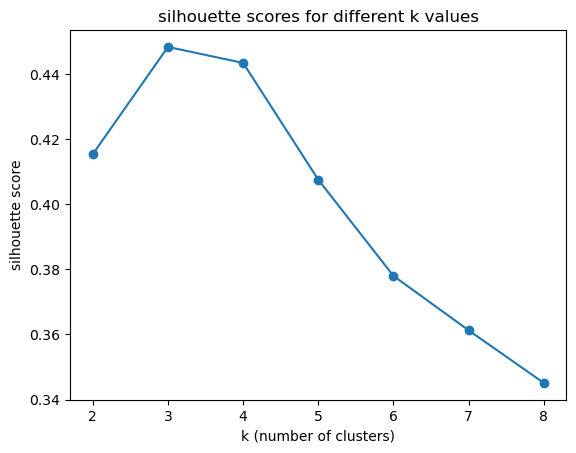

In [37]:
# Plotting the silhouette scores so it's easier to see which k looks best

# Making lists for plotting (k values and the scores)
k_values = list(silhouette_scores.keys())
scores = list(silhouette_scores.values())

# Sorting by k just in case (so the line goes in the right order)
k_values_sorted = sorted(k_values)
scores_sorted = [silhouette_scores[k] for k in k_values_sorted]

plt.figure()
plt.plot(k_values_sorted, scores_sorted, marker="o")
plt.xlabel("k (number of clusters)")
plt.ylabel("silhouette score")
plt.title("silhouette scores for different k values")
plt.xticks(k_values_sorted)  # show every k on the x-axis
plt.show()

#### 8. Fiting k-means and interpreting the clusters

In [38]:
#Fitting the model based on the best silhouette score

k_final = 3 

kmeans = KMeans(n_clusters=k_final, random_state=50, n_init=20)
labels = kmeans.fit_predict(uk_scaled)

results = pd.DataFrame({
    "source": uk_scaled.index,
    "cluster": labels
})

print("cluster sizes:")
print(results["cluster"].value_counts().sort_index())

cluster sizes:
cluster
0    187
1    231
2    177
Name: count, dtype: int64


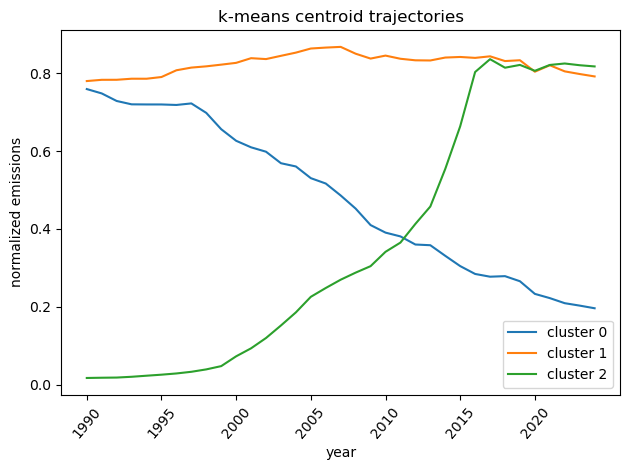

In [39]:
# Plotting the k-means results

centroids_scaled = kmeans.cluster_centers_  # centroids in the scaled space
centroids_norm = scaler.inverse_transform(centroids_scaled)  # putting it back to normalized space

years = list(uk_normalized.columns)

plt.figure()
for c in range(k_final):
    plt.plot(years, centroids_norm[c], label= "cluster " + str(c))

plt.xlabel("year")
plt.ylabel("normalized emissions")
plt.title("k-means centroid trajectories")
plt.xticks(years[::5], rotation=50)
plt.legend()
plt.tight_layout()
plt.show()

In [40]:
# Adding the sector labels to the sources

sector_map = (
    uk_filtered.groupby("Source")["Territorial Emissions Statistics sector"]
    .apply(lambda s: s.value_counts().idxmax())
)

results["sector"] = results["source"].map(sector_map)

print(results[["source", "cluster", "sector"]].head())

                               source  cluster       sector
0      Abandoned oil wells (offshore)        1  Fuel supply
1       Abandoned oil wells (onshore)        1  Fuel supply
2        Accidental fires - dwellings        0        Waste
3  Accidental fires - other buildings        0        Waste
4         Accidental fires - vehicles        0        Waste


In [41]:
# Adding average emissions per source 

avg_emissions = uk_wide_filtered.mean(axis=1)
results["avg_mtco2e"] = results["source"].map(avg_emissions)

print(results[["source", "cluster", "avg_mtco2e"]].head())

                               source  cluster  avg_mtco2e
0      Abandoned oil wells (offshore)        1    0.000060
1       Abandoned oil wells (onshore)        1    0.000601
2        Accidental fires - dwellings        0    0.005793
3  Accidental fires - other buildings        0    0.008889
4         Accidental fires - vehicles        0    0.001452


In [42]:
# Showing only the top 10 sources for each cluster (easier to read)

clusters = sorted(results["cluster"].unique())

for c in clusters:
    print("\n====================")
    print("Cluster", c, "(top 10 by avg emissions)")
    print("====================")

    # Take only rows from this cluster
    top_c = results[results["cluster"] == c]

    # Sort by average emissions (largest first)
    top_c = top_c.sort_values("avg_mtco2e", ascending=False)

    # Keep only the top 10 rows
    top_c = top_c.head(10)

    # Reset the index so it prints nicely
    top_c = top_c.reset_index(drop=True)

    # Rounding the numbers for readability
    top_c["avg_mtco2e"] = top_c["avg_mtco2e"].round(3)

    # Printing only the important columns
    print(top_c[["source", "sector", "avg_mtco2e"]])


Cluster 0 (top 10 by avg emissions)
                                              source  \
0                                     Power stations   
1                                           Landfill   
2                        Other industrial combustion   
3                           Public sector combustion   
4                             Chemicals (combustion)   
5                  Iron and steel - combustion plant   
6                                        Gas leakage   
7  Net carbon stock change in soils - Mineral Soi...   
8                                    Deep-mined coal   
9                 Food & drink, tobacco (combustion)   

                       sector  avg_mtco2e  
0          Electricity supply     136.281  
1                       Waste      36.324  
2                    Industry      17.848  
3  Buildings and product uses      12.152  
4                    Industry      11.746  
5                    Industry      11.282  
6                 Fuel supply       6.

In [43]:
# Finding the main fuel group for each source
# The fuel group that contributes the most emissions for that source overall


fuel_totals = (
    uk_filtered.groupby(["Source", "Fuel group"])["Emissions (MtCO2e)"]
    .sum()
    .reset_index()
)

# For each Source, keep the row with the biggest emissions total
fuel_totals = fuel_totals.sort_values(["Source", "Emissions (MtCO2e)"], ascending=[True, False])
main_fuel = fuel_totals.drop_duplicates(subset=["Source"], keep="first")

# Making a simple dictionary: source -> main fuel group
main_fuel_map = dict(zip(main_fuel["Source"], main_fuel["Fuel group"]))

# Adding it to your results table
results["main_fuel_group"] = results["source"].map(main_fuel_map)

print(results[["source", "cluster", "main_fuel_group"]].head())

                               source  cluster  main_fuel_group
0      Abandoned oil wells (offshore)        1  Other emissions
1       Abandoned oil wells (onshore)        1  Other emissions
2        Accidental fires - dwellings        0  Other emissions
3  Accidental fires - other buildings        0  Other emissions
4         Accidental fires - vehicles        0  Other emissions


In [44]:
# Fuel group counts per cluster

fuel_counts = (
    results.groupby(["cluster", "main_fuel_group"])
    .size()
    .reset_index(name="count")
    .sort_values(["cluster", "count"], ascending=[True, False])
)

print(fuel_counts.head(100))

    cluster    main_fuel_group  count
2         0    Other emissions    152
4         0          Petroleum     14
1         0      Gaseous fuels     13
0         0               Coal      5
3         0  Other solid fuels      3
6         1    Other emissions    180
8         1          Petroleum     33
5         1      Gaseous fuels     15
7         1  Other solid fuels      3
11        2    Other emissions    165
13        2          Petroleum      6
9         2               Coal      2
10        2      Gaseous fuels      2
12        2  Other solid fuels      2


In [45]:
# Top 10 sectors for each cluster (by how many sources)

clusters = sorted(results["cluster"].unique())

for c in clusters:
    print("\n====================")
    print("Cluster", c, "- top 10 sectors")
    print("====================")

    # only rows from this cluster
    temp = results[results["cluster"] == c]

    # count how many sources in each sector
    counts = temp["sector"].value_counts()

    # show the top 10
    print(counts.head(10))


Cluster 0 - top 10 sectors
sector
LULUCF                        46
Industry                      42
Agriculture                   36
Fuel supply                   34
Domestic transport            12
Waste                          9
Buildings and product uses     7
Electricity supply             1
Name: count, dtype: int64

Cluster 1 - top 10 sectors
sector
Agriculture                   85
LULUCF                        67
Domestic transport            25
Industry                      20
Waste                         15
Buildings and product uses    10
Fuel supply                    9
Name: count, dtype: int64

Cluster 2 - top 10 sectors
sector
Agriculture                   82
LULUCF                        38
Buildings and product uses    27
Industry                      12
Domestic transport            12
Waste                          6
Name: count, dtype: int64


### 2.2 Explanation of the variables used and interpretation of the clusters

#### Variables used: 

For the clustering, we used emissions levels (Emissions (MtCO2e)) for each Source across years 1990–2024. We normalized each source by its own maximum value (so each time series is on a 0–1 scale) and applied standard scaling before running k-means. This way we could compare sources based on the shape of their emissions trajectories (declining vs stable vs increasing) rather than clustering by the size of the emission sources (like clustering by big emitters vs small emitters). This aligns with what the assignment outline asked of us. 

We also tried but ended up avoiding alternative solutions such as using 1990 = 100 baseline indexing because many sources don’t have reliable 1990 values (which can force you to drop lots of sources or create extreme ratios) and in the end, we didn’t use year-to-year % changes or log changes as the main features because they got very noisy and unstable because many of the emission sources have values close to zero, which created a lot of spikes that dominated the clustering too much.

We also didn't use fuel group as a clustering variable (even though it's mentioned in the assignment outline) because it’s a categorical label so if we encode it, the clustering could have ended up grouping sources mainly by the category labels rather than by how their emissions evolve over time.

#### Interpretation of the clustering results:

The k-means clustering algorithm basically found three common trajectory shapes across the years 1990–2024. These are: a declining group (cluster 0), a flat group for which the emission levels stay high throughout the years (cluster 1), and a strongly increasing group in which relative emission levels have risen in the past 25 years (cluster 2). 

Cluster 0 is the one that most clearly shows the UK’s decarbonisation. Its biggest sources include Power stations (Electricity supply), plus Landfill, industrial combustion and deep-mined coal. Power stations and other big burning fuel sources are going down because the UK has stopped using as much coal and carbon fuels to make electricity and has switched more to cleaner energy. When the power system changes like that, emissions drop a lot even if people still use a lot of electricity.

Cluster 1 is different because it stays high across the whole period and the biggest sources of it are Domestic space/water heating, road transport (cars and urban/rural/motorway driving), and Enteric (agriculture). For cars and home heating, emissions come from lots of households and drivers, not a small number of power stations. And because of this, changes happen slower because they depend a lot on people's behavior which is more difficult to control, and for transport and heating, the clean energy replacements take longer to adopt. 

Cluster 2 has an upward trend in emissions. It starts near zero in the early years and rises a lot later on, and the top sources are things like commercial refrigeration, mobile air-conditioning, and other smaller categories (plus some waste treatment items). This doesn’t mean these are the biggest emitters (their average emission value is much smaller than Cluster 0 and 1). It shows that when the UK cuts the big sources of emissions, the smaller sources start to matter more. In other words, once the main problem areas are reduced, you can see that some newer types of emissions are growing compared to how they used to be, so they become a bigger part of the overall picture.

### 2.3 Relating clustering results to UK climate policy


#### Explanation:

As mentioned in the previous question, cluster 0 is made up of mainly power stations, landfill and other big industrial sources, cluster is mostly domestic space and water heating, road transport, and enteric (agriculture) and finally cluster 2 is made up of smaller and newer sources such as commercial refrigeration, airconditioning and some waste treatment items. Looking at Appendix F of the UK's Carbon Budget and Growth Delivery plan, the plan expects the power sector to change a lot, because the policies are designed to help the UK move away from fossil fuel electricity and build a cleaner electricity system. It also expects big emissions cuts from fuel supply and industry, mainly by making oil and gas operations cleaner. This aligns with the declining pattern of cluster 0. It makes sense that Cluster 0 drops over time, because these are sectors where the UK can make big changes at the system level. Because these emissions come from a few large sources, policy changes can reduce them faster. 

Even though the Carbon Budget pln also targets the heating of buildings and transport, cluster 1 stays much more stagnant because these emissions are tied to everyday life, which means that changes rely on millions of households switching boilers or improving insulation or buying EVs. Those changes take more time and cost money for individuals. So likely because these decisions depend on consumer choices, the reductions are slower than in the power sector. The same goes for agriculture, where a big part of emissions is likely from livestock. That’s why cluster 1 likely represents the more resistant part of UK emissions.

For the sectors included in cluster 2, the plan also discusses the areas of waste and F-gases such as for refrigeration and air conditioning. These sources are smaller in total emissions compared to power or transport, but they stand out because they are increasing relative to their own history. This is explained by the fact that as the UK cuts the big traditional sources, these newer sources become more noticeable in overall emissions. So Cluster 2 suggests areas that are increasingly important for future Carbon Budget progress, even if they are not the largest contributors today.

<h2 style="color:darkgreen;">Question 3. Policy Interpretation and Critical Analysis</h2>

### 3.1 Emissions Trends Internavional Aviation vs Shipping affecting progress assessment against UK Carbon Budgets


In [46]:
# Total emissions (including IAS)
with_ias = df.groupby("Year")["Emissions (MtCO2e)"].sum()

# Territorial total (excluding IAS)
without_ias = (
    df[df["Included in UK territorial total"] == "Yes"]
    .groupby("Year")["Emissions (MtCO2e)"]
    .sum()
)

# Combine into one table
territorial_compare = pd.DataFrame({
    "With IAS": with_ias,
    "Without IAS (Territorial total)": without_ias
}).sort_index()

# Make sure years are in chronological order
territorial_compare = territorial_compare.sort_index()

territorial_compare.head()

,With IAS,Without IAS (Territorial total)
Year,,
1990,812.838154,790.824097
1991,822.082963,800.562403
1992,803.700111,780.372663
1993,785.797722,761.353063
1994,773.300168,748.650618


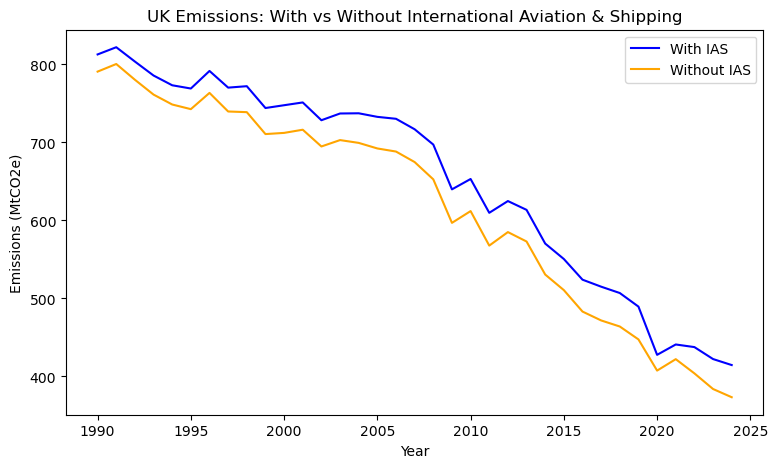

Percent change (With IAS): -48.99%
Percent change (Without IAS - Territorial total): -52.78%


In [47]:
# ---------------------------
# 1) PLOT COMPARISON
# ---------------------------

plt.figure(figsize=(9,5))

# Plot total emissions including IAS
plt.plot(
    territorial_compare.index,
    territorial_compare["With IAS"],
    label="With IAS",
    color="blue"
)

# Plot territorial total (excluding IAS)
plt.plot(
    territorial_compare.index,
    territorial_compare["Without IAS (Territorial total)"],
    label="Without IAS",
    color="orange"
)
plt.xlabel("Year")
plt.ylabel("Emissions (MtCO2e)")
plt.title("UK Emissions: With vs Without International Aviation & Shipping")
plt.legend()

plt.show()

# ---------------------------
# 2) CALCULATE PERCENTAGE CHANGE
# ---------------------------

def pct_change(series):
    """
    Calculates percentage change from first to last year.
    Drops missing values for safety.
    """
    series = series.dropna()
    
    # Avoid division by zero or any insufficient data
    if len(series) < 2 or series.iloc[0] == 0:
        return None
    
    return (series.iloc[-1] - series.iloc[0]) / series.iloc[0] * 100


# Calculate percentage changes
pct_with = pct_change(territorial_compare["With IAS"])
pct_without = pct_change(territorial_compare["Without IAS (Territorial total)"])

# Then we print results clearly formatted
print(f"Percent change (With IAS): {pct_with:.2f}%")
print(f"Percent change (Without IAS - Territorial total): {pct_without:.2f}%")

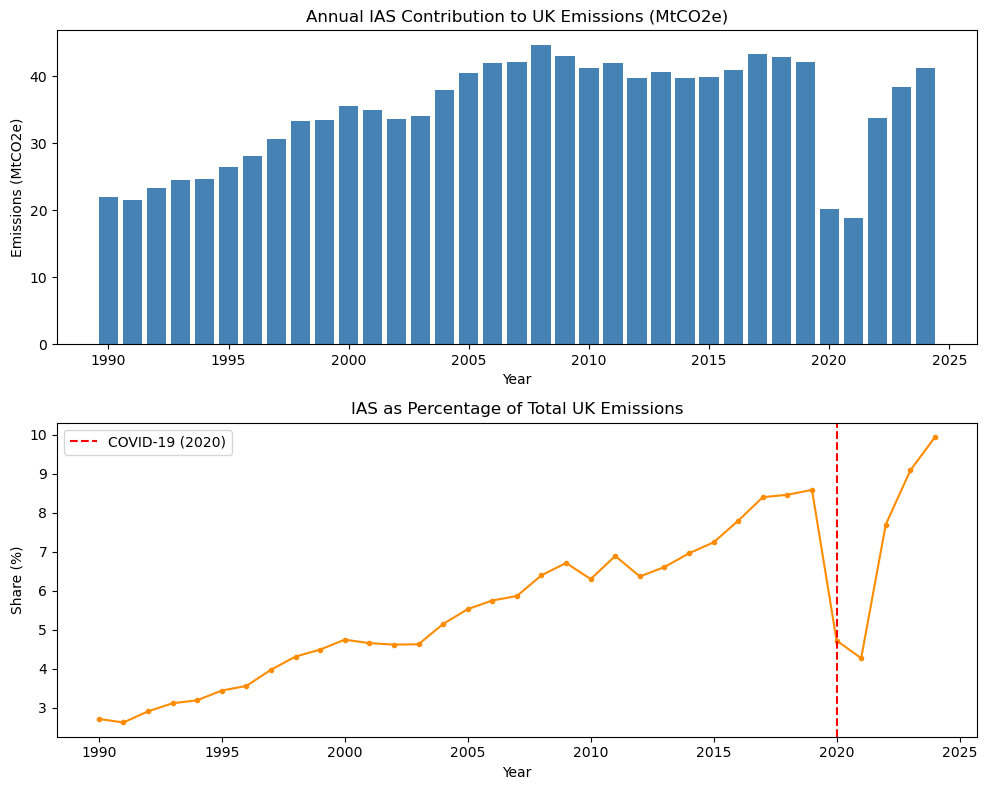

In [48]:
# ---------------------------------------
# 3. VISUALISING IAS CONTRIBUTION
# ---------------------------------------

# We decide to create two stacked plots:

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

# Calculate IAS contribution (absolute difference)
territorial_compare["IAS Contribution"] = (
    territorial_compare["With IAS"] -
    territorial_compare["Without IAS (Territorial total)"]
)

# Calculate IAS share (% of total emissions)
territorial_compare["IAS Share (%)"] = (
    territorial_compare["IAS Contribution"] /
    territorial_compare["With IAS"] * 100
)
# --- Plot 1: Absolute IAS contribution ---
ax1.bar(
    territorial_compare.index,
    territorial_compare["IAS Contribution"],
    color="steelblue"
)

ax1.set_title("Annual IAS Contribution to UK Emissions (MtCO2e)")
ax1.set_ylabel("Emissions (MtCO2e)")
ax1.set_xlabel("Year")


# --- Plot 2: IAS share of total emissions (%) ---
ax2.plot(
    territorial_compare.index,
    territorial_compare["IAS Share (%)"],
    color="darkorange",
    marker="o",
    markersize=3
)

ax2.set_title("IAS as Percentage of Total UK Emissions")
ax2.set_ylabel("Share (%)")
ax2.set_xlabel("Year")

# Also highlight COVID-19 year
ax2.axvline(x=2020, color="red", linestyle="--", label="COVID-19 (2020)")
ax2.legend()

plt.tight_layout()
plt.show()

In [49]:
# --- Pre / During / Post COVID comparison ---

pre_covid_avg = territorial_compare.loc[2015:2019, "IAS Share (%)"].mean()
covid_share = territorial_compare.loc[2020, "IAS Share (%)"]
post_covid_avg = territorial_compare.loc[2021:, "IAS Share (%)"].mean()

print(f"Average IAS share 2015–2019 (pre-COVID):  {pre_covid_avg:.2f}%")
print(f"IAS share in 2020 (COVID collapse):       {covid_share:.2f}%")
print(f"Average IAS share 2021+ (recovery):       {post_covid_avg:.2f}%")

Average IAS share 2015–2019 (pre-COVID):  8.10%
IAS share in 2020 (COVID collapse):       4.72%
Average IAS share 2021+ (recovery):       7.75%


#### Explanation: 
Both emission measures show a strong and sustained decline in UK emissions from 1990 onwards. Total emissions fell by approximately 49% when including international aviation and shipping (IAS), and by around 53% under the territorial definition that excludes IAS. This confirms substantial long-term progress in reducing greenhouse gas emissions.

The difference we found between the two measures is relatively small in absolute terms. In 1990, the gap was about 22 MtCO₂e, representing only around 2–3% of total emissions. Although IAS emissions increased gradually as a share of total emissions over time, reaching around 8–10% in recent years before the temporary COVID-19 collapse, they remain to have a modest component of overall UK emissions.

Since UK Carbon Budgets are assessed using territorial emissions (which exclude IAS), the official measure shows a slightly larger percentage reduction. However, because the IAS contribution remains relatively small compared to total emissions, including or excluding IAS does not fundamentally change the overall assessment of the long-term progress they are making.

This indicates that while accounting boundaries matter conceptually for policy evaluation, in practice the difference between territorial and broader emission measures does not significantly alter the conclusion that the UK has achieved substantial emission reductions since 1990.

### 3.2 Emissions covered under the UK's Paris Agreement, and the implications of this coverage for interpreting emission reduction performance

In [50]:
# ---------------------------------------------------------
# Paris Agreement coverage table (emissions) for one year
# ---------------------------------------------------------
def paris_coverage_emissions(df, year):
    df = df.copy()

    # Filter dataset to the chosen year
    dfy = df[df["Year"] == year]

    # Sum emissions by sector, split by Paris coverage (Yes/No)
    table = (
        dfy.groupby(
            ["Territorial Emissions Statistics sector", "Included in UK Paris Agreement total"]
        )["Emissions (MtCO2e)"]
        .sum()
        .unstack(fill_value=0)
    )

    # Ensure both Yes and No exist
    table = table.reindex(columns=["Yes", "No"], fill_value=0)

    # Rename columns to be more readable
    table.columns = ["Included", "Excluded"]

    # Add totals and coverage percentage
    table["Total"] = table["Included"] + table["Excluded"]
    table["Covered (%)"] = (table["Included"] / table["Total"] * 100).round(1)

    # Made sure to round numbers
    return year, table.round(1)


# -----------------------------
# Create tables for 1990 and 2024 to be able to compare them
# -----------------------------
y1990, table_1990 = paris_coverage_emissions(unfccc_df, 1990)
ylatest, table_latest = paris_coverage_emissions(unfccc_df, 2024) 

print(f"Paris Agreement coverage by sector (Emissions) — {y1990}")
display(table_1990)

print(f"Paris Agreement coverage by sector (Emissions) — {ylatest}")
display(table_latest)

Paris Agreement coverage by sector (Emissions) — 1990


,Included,Excluded,Total,Covered (%)
Territorial Emissions Statistics sector,,,,
Agriculture,55.2,0.3,55.5,99.5
Buildings and product uses,110.0,0.1,110.1,99.9
Domestic transport,126.2,0.7,126.9,99.4
Electricity supply,204.6,0.6,205.2,99.7
Fuel supply,77.2,0.0,77.2,100.0
Industry,155.8,0.0,155.8,100.0
LULUCF,10.2,0.1,10.3,99.2
Waste,55.2,0.1,55.3,99.8


Paris Agreement coverage by sector (Emissions) — 2024


,Included,Excluded,Total,Covered (%)
Territorial Emissions Statistics sector,,,,
Agriculture,46.7,0.2,46.8,99.7
Buildings and product uses,82.1,0.3,82.5,99.6
Domestic transport,111.5,1.0,112.5,99.1
Electricity supply,38.0,0.9,39.0,97.6
Fuel supply,28.8,0.0,28.8,100.0
Industry,46.6,0.0,46.6,100.0
LULUCF,0.2,0.1,0.3,70.0
Waste,21.5,0.1,21.7,99.3


In [51]:
# Show the largest excluded sector in each year
for label, tbl in [("1990", table_1990), ("Latest", table_latest)]:
    sector = tbl["Excluded"].idxmax()
    excluded = tbl.loc[sector, "Excluded"]
    share = (excluded / tbl.loc[sector, "Total"] * 100) if tbl.loc[sector, "Total"] != 0 else 0
    print(f"{label}: largest excluded sector = {sector} ({excluded:.1f} MtCO2e, {share:.1f}% of that sector)")

1990: largest excluded sector = Domestic transport (0.7 MtCO2e, 0.6% of that sector)
Latest: largest excluded sector = Domestic transport (1.0 MtCO2e, 0.9% of that sector)


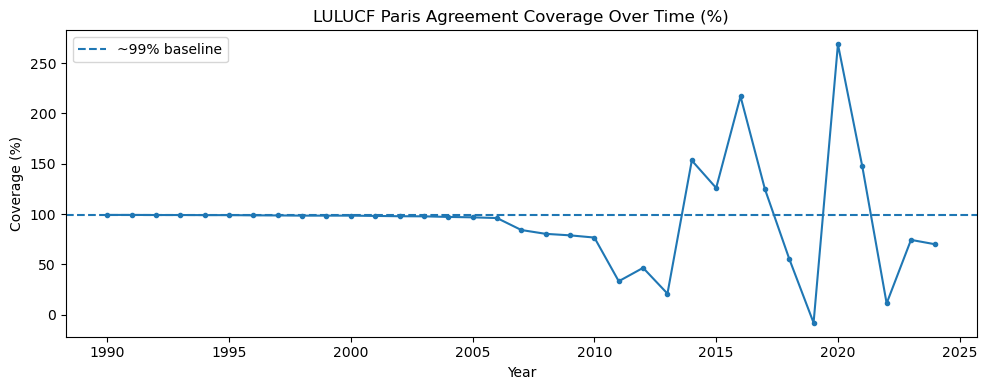

In [52]:
# Decided to track LULUCF coverage over time using a visualisation plot
years_available = sorted(unfccc_df["Year"].dropna().unique().astype(int))

lulucf_coverage = []

for yr in years_available:
    _, t = paris_coverage_emissions(unfccc_df, yr)  # returns (year_used, table)
    if "LULUCF" in t.index:
        lulucf_coverage.append({
            "Year": yr,
            "Covered (%)": t.loc["LULUCF", "Covered (%)"]
        })

lulucf_df = pd.DataFrame(lulucf_coverage).set_index("Year")

# Plot LULUCF coverage trend
plt.figure(figsize=(10,4))
plt.plot(lulucf_df.index, lulucf_df["Covered (%)"], marker="o", markersize=3)
plt.axhline(y=99, linestyle="--", label="~99% baseline")
plt.title("LULUCF Paris Agreement Coverage Over Time (%)")
plt.ylabel("Coverage (%)")
plt.xlabel("Year")
plt.legend()
plt.tight_layout()
plt.show()

In [53]:
# To have a better look as well, we compare total excluded emissions (1990 vs 2024)

total_excluded_1990 = table_1990["Excluded"].sum()
total_1990 = table_1990["Total"].sum()

total_excluded_2024 = table_latest["Excluded"].sum()
total_2024 = table_latest["Total"].sum()

pct_1990 = (total_excluded_1990 / total_1990 * 100) if total_1990 != 0 else 0
pct_2024 = (total_excluded_2024 / total_2024 * 100) if total_2024 != 0 else 0

print(f"Total excluded emissions 1990: {total_excluded_1990:.1f} MtCO2e ({pct_1990:.2f}% of total)")
print(f"Total excluded emissions 2024: {total_excluded_2024:.1f} MtCO2e ({pct_2024:.2f}% of total)")

Total excluded emissions 1990: 1.9 MtCO2e (0.24% of total)
Total excluded emissions 2024: 2.6 MtCO2e (0.69% of total)


#### Explanation: 
All eight major sectors are included in Paris Agreement reporting: Agriculture, Buildings and product uses, Domestic transport, Electricity supply, Fuel supply, Industry, LULUCF, and Waste. In the the coverage tables we can see that almost all UK emissions are captured within this framework. In both 1990 and 2024, every sector has coverage above 97%, with Fuel supply and Industry at 100% throughout. This near-complete coverage means that when the UK reports emission reductions under the Paris Agreement, those figures reflect genuine national progress rather than selective exclusion of high-emitting sources. It also means UK figures are directly comparable to other Paris Agreement signatories, strengthening the validity of any international performance benchmarking.
The only exception we found is LULUCF, which falls to 70% coverage by 2024. However, this is less alarming than it appears for two reasons. The coverage chart shows it fluctuates wildly; even exceeding 100% in some years; because LULUCF can switch between being an emissions source and a carbon sink depending on land use changes, making consistent reporting difficult. As well as, LULUCF's total emissions shrank from 10.3 MtCO2e in 1990 to just 0.3 MtCO2e in 2024, so the excluded portion has minimal impact on the overall reported performance figure.
In short, the Paris Agreement captures UK emissions comprehensively enough that reported reduction figures can be trusted as a genuine measure of national progress.

### 3.3 Findings whether historical emissions trends align with long-term climate targets

In [54]:
# ----------------------------
# 1) BUILD WIDE SECTOR DATASET
# ----------------------------
uk_df = uk_df.copy()
uk_df["Year"] = pd.to_numeric(uk_df["Year"], errors="coerce")

df1_wide = (
    uk_df.dropna(subset=["Year"])
         .groupby(["Year", "Territorial Emissions Statistics sector"])["Emissions (MtCO2e)"]
         .sum()
         .unstack(fill_value=0)   # wide format: sectors become columns
         .sort_index()
)

df1_wide.head()

# --------------------------------------
# 2) SUMMARY TABLE: % CHANGE + CORRELATION
# --------------------------------------
summary = []

for sector in df1_wide.columns:
    series = df1_wide[sector]

    # Skip if not enough data or first value is 0 (avoids divide-by-zero)
    if len(series) < 2 or series.iloc[0] == 0:
        continue

    years = series.index.values  # years match automatically

    pct_change = (series.iloc[-1] - series.iloc[0]) / series.iloc[0] * 100
    corr_time = correlation(series.values, years)

    summary.append({
        "Sector": sector,
        "Percent Change (%)": round(pct_change, 1),
        "Correlation with Time": round(corr_time, 3)
    })

summary_table = pd.DataFrame(summary).sort_values("Percent Change (%)")
summary_table

,Sector,Percent Change (%),Correlation with Time
7,LULUCF,-97.2,-0.937
3,Electricity supply,-81.5,-0.863
5,Industry,-70.1,-0.984
4,Fuel supply,-62.7,-0.992
8,Waste,-61.0,-0.932
1,Buildings and product uses,-25.3,-0.856
0,Agriculture,-15.4,-0.927
2,Domestic transport,-11.1,-0.549
6,International aviation and shipping,87.3,0.497


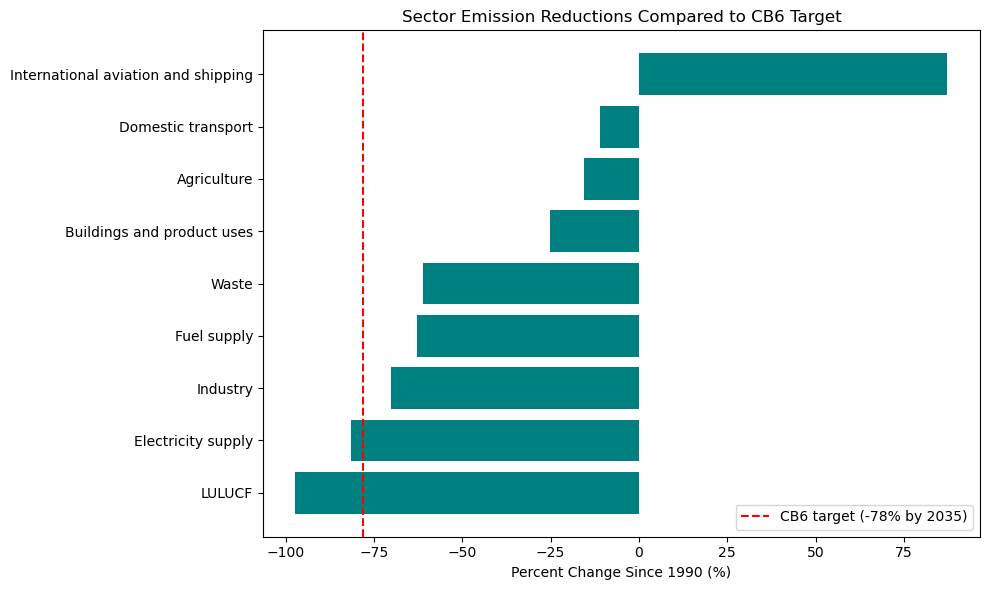

In [55]:
# -----------------------------
# 3) PLOT: SECTOR REDUCTIONS VS CB6 TARGET
# -----------------------------

cb6_target = -78.0  # CB6 implied target: ~78% reduction from 1990 by 2035

# Sort sectors so the biggest reductions appear at the top (easy to read)
plot_df = summary_table.sort_values("Percent Change (%)").copy()

plt.figure(figsize=(10, 6))
plt.barh(plot_df["Sector"], plot_df["Percent Change (%)"], color="teal")
plt.axvline(cb6_target, color="red", linestyle="--", label="CB6 target (-78% by 2035)") # Dashed vertical line showing the CB6 target (-78%)
plt.xlabel("Percent Change Since 1990 (%)")
plt.title("Sector Emission Reductions Compared to CB6 Target")
plt.legend()
plt.tight_layout()
plt.show()

#### Explanation:
The UK has reduced total emissions by around 50% since 1990, but the pattern of reductions reveals a deeper structural story. The sectors that have decarbonised fastest; electricity supply (-81.5%) and fuel supply (-62.7%); are centralised industries where the government can drive change by regulating a relatively small number of large producers. Switching power stations from coal to renewables, for example, does not require changing the behaviour of millions of people. This is why these sectors show near-perfect correlations with time (-0.863 and -0.992), reflecting consistent, policy-driven structural change.
In contrast, the sectors furthest from the CB6 target are all ones that depend on changing individual behaviour. Buildings (-25.3%), Agriculture (-15.4%), and Domestic transport (-11.1%) require millions of households, farmers, etc. to change how they heat their homes, manage their land, and travel. This is structurally much harder to achieve through policy, which explains why progress in these sectors has been slow and inconsistent. Domestic transport's weak correlation of -0.549 is particularly telling basically that reductions in this sector have not followed a consistent downward trend, suggesting no real structural change has occurred, just short-term fluctuations.
International aviation and shipping (+87.3%) reveals another side of the problem. This is the one sector where emissions have actually grown, yet it sits outside Carbon Budget accounting. This means the UK's headline 50% reduction partly flatters the true picture by excluding a category that has been moving in the wrong direction throughout the period.
In short, the UK's progress is real but structurally complex. It has been driven by changes that were relatively easy to implement centrally, while the harder challenge of decarbonising behaviour-dependent sectors remains largely unresolved. Until those sectors show the kind of consistent decline visible in energy and industry, the UK's alignment with long-term climate targets remains dependent on continued gains in the sectors that have already done most of the reductions.